# 🫁 CXR DenseNet121 — v6.2 (FINE-TUNING parcial · CPU · pesado · modelo independiente)
## TFM · Módulo de Imagen · Universidad de Salamanca

---

Versión **pesada** del CXR. A diferencia de v6/v6.1 (backbone **congelado** + embeddings cacheados, techo ~0.80-0.82),
aquí se **descongela el último bloque del DenseNet121 y se entrena de principio a fin (fine-tuning)**, que es el
verdadero palanca para mejorar. Modelo **independiente** (sin fusión).

## 🆙 Qué cambia respecto a v6.1

| Cambio | Detalle |
|---|---|
| **Fine-tuning parcial** | Se descongela el último bloque denso (`denseblock4 + norm5`) y se entrena junto con la cabeza. El resto del backbone sigue congelado (BatchNorm del backbone en modo eval = estadísticas CheXNet). |
| **Entrenamiento end-to-end sobre imágenes** | Ya no hay embeddings cacheados; cada época pasa las imágenes por el backbone (por eso es lento). |
| **LR diferencial** | LR bajo para el backbone descongelado (1e-5) y mayor para la cabeza (1e-3). |
| **Aumento de imagen real** | flips, rotaciones, brillo/contraste durante el entrenamiento. |
| **TTA** | en test se promedian varias vistas aumentadas (test-time augmentation). |
| **Cabeza profunda** | igual que v6.1 (768→384→192→6). |

Se mantiene: **negativos derivados por exclusividad** (No Finding), **masking de NaN/−1 intacto**, `pos_weight` dinámico,
BCE/focal, **calibración isotónica**, metadatos (18 dims), y salidas ricas.

## ⏱️ Coste (CPU, i5-1135G7, sin GPU)

**ALTO**: el fine-tuning pasa todas las imágenes por el backbone cada época. Estimación ≈ **40-60 min/época** →
con `FINAL_EPOCHS≈8` son **varias horas (corrida nocturna)**. Ajusta `FINAL_EPOCHS`, `UNFREEZE_DEEP`, `BATCH`, o
`FAST_MODE=True` para una prueba. Por coste, **no se hace K-fold** aquí: un único modelo final (train completo + val).

## 🎯 Expectativa honesta

v6.1 ya daba ~0.80 macro. El fine-tuning parcial suele aportar una mejora **modesta pero real** (orientativo
0.80 → 0.82-0.85). No esperes saltos enormes: el dataset y las etiquetas tienen su techo.


In [16]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","torchvision","--index-url","https://download.pytorch.org/whl/cpu","-q"],check=True)
for pkg in ["torchxrayvision","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"],check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [17]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchxrayvision as xrv
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES=4; torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"]=str(N_CORES); os.environ["MKL_NUM_THREADS"]=str(N_CORES)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · xrv {xrv.__version__} · {DEVICE} · hilos {torch.get_num_threads()}")


PyTorch 2.8.0+cpu · xrv 1.4.0 · cpu · hilos 4


In [18]:
# CELDA 3 · RUTAS Y CONSTANTES (v6.2)
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
NPY=BASE/"data_npy"
CXR_TRAIN_NPY,CXR_VAL_NPY,CXR_TEST_NPY=NPY/"train"/"cxr_train.npy",NPY/"val"/"cxr_val.npy",NPY/"test"/"cxr_test.npy"
HADM_TRAIN_NPY,HADM_VAL_NPY,HADM_TEST_NPY=NPY/"train"/"hadm_id_train.npy",NPY/"val"/"hadm_id_val.npy",NPY/"test"/"hadm_id_test.npy"
OUTPUT_DIR=Path("outputs_cxr_densenet121_v6_2").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
IMG_SIZE=224; XRV_RANGE=1024.0; BACKBONE_WEIGHTS="densenet121-res224-all"
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True

GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
CXR_VIEW_MAP={"AP":0,"PA":1}; RACE_ONEHOT=5
META_DIM=1+1+RACE_ONEHOT+len(ADMISSION_MAP)+len(ADM_LOC_MAP)+1+len(CXR_VIEW_MAP)  # 18

# --- Fine-tuning ---
FAST_MODE=False
FINAL_EPOCHS=8 if not FAST_MODE else 2
PATIENCE=4
BATCH=16
LR_HEAD=1e-3; LR_BACKBONE=1e-5; WEIGHT_DECAY=1e-4
UNFREEZE_DEEP=False        # True = descongela también denseblock3 (más lento, quizá algo mejor)
DROPOUT=0.4; USE_FOCAL=False; UNCERTAINTY_POLICY="ones"   # 'ones' fue lo mejor en v6.1
TTA=True                   # test-time augmentation
print(f"v6.2 · épocas={FINAL_EPOCHS} batch={BATCH} unfreeze_deep={UNFREEZE_DEEP} policy={UNCERTAINTY_POLICY} FAST={FAST_MODE}")


Salidas en: C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_cxr_densenet121_v6_2
v6.2 · épocas=8 batch=16 unfreeze_deep=False policy=ones FAST=False


In [19]:
# CELDA 4 · CARGA Y ALINEACIÓN CSV <-> NPY
def load_split(csv,cxr,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(cxr,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con imagen={len(df):,} · CXR {a.shape}"); return df,a
df_train,cxr_train=load_split(TRAIN_CSV,CXR_TRAIN_NPY,HADM_TRAIN_NPY,"train")
df_val,cxr_val=load_split(VAL_CSV,CXR_VAL_NPY,HADM_VAL_NPY,"val")
df_test,cxr_test=load_split(TEST_CSV,CXR_TEST_NPY,HADM_TEST_NPY,"test")


train: CSV=10,000 con imagen=10,000 · CXR (10000, 3, 320, 320)
val  : CSV=750 con imagen=750 · CXR (750, 3, 320, 320)
test : CSV=464 con imagen=464 · CXR (4640, 3, 320, 320)


In [20]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados)
def build_targets(df,uncertainty_policy=UNCERTAINTY_POLICY,derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,verbose=True)
y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)


   Neg. derivados patologías=6,091 · No Finding=7,691


In [21]:
# CELDA 6 · METADATOS (18 dims)
AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
def build_metadata(df):
    N=len(df); M=np.zeros((N,META_DIM),np.float32)
    for i,(_,r) in enumerate(df.iterrows()):
        o=0
        M[i,o]=(float(r.get("age",AGE_MIN))-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8); o+=1
        M[i,o]=float(GENDER_MAP.get(r.get("gender",0),0)); o+=1
        M[i,o+RACE_MAP.get(str(r.get("race","UNKNOWN")).upper(),0)]=1.0; o+=RACE_ONEHOT
        M[i,o+ADMISSION_MAP.get(str(r.get("admission_type","EMERGENCY")).upper(),1)]=1.0; o+=len(ADMISSION_MAP)
        M[i,o+ADM_LOC_MAP.get(str(r.get("admission_location","EMERGENCY_ROOM")).upper(),0)]=1.0; o+=len(ADM_LOC_MAP)
        M[i,o]=(float(r.get("hours_adm_to_cxr",HRS_MIN))-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8); o+=1
        M[i,o+CXR_VIEW_MAP.get(str(r.get("cxr_view","AP")).upper(),0)]=1.0; o+=len(CXR_VIEW_MAP)
    return M
meta_train,meta_val,meta_test=build_metadata(df_train),build_metadata(df_val),build_metadata(df_test)
print("Metadatos:",meta_train.shape,meta_val.shape,meta_test.shape)


Metadatos: (10000, 18) (750, 18) (464, 18)


In [22]:
# CELDA 7 · DATASET DE IMÁGENES (xrv-normalize) + AUMENTO en train
def _prep_img(arr):
    g=arr[0] if arr.ndim==3 else arr
    g=g.astype(np.float32); g=(g-g.min())/(g.max()-g.min()+1e-8); g=(2.0*g-1.0)*XRV_RANGE
    return g  # (H,W) en [-1024,1024]

class CXRDataset(Dataset):
    def __init__(s,df,cxr,meta,y,m,augment=False):
        s.idx=df["_npy_idx"].to_numpy(); s.cxr=cxr; s.meta=meta; s.y=y; s.m=m; s.aug=augment
    def __len__(s): return len(s.idx)
    def __getitem__(s,i):
        g=_prep_img(np.asarray(s.cxr[int(s.idx[i])],np.float32))
        t=torch.from_numpy(g)[None,None]
        t=F.interpolate(t,size=(IMG_SIZE,IMG_SIZE),mode="bilinear",align_corners=False)[0]  # (1,224,224)
        if s.aug:
            if np.random.rand()<0.5: t=torch.flip(t,dims=[2])                       # flip horizontal
            ang=np.random.uniform(-8,8)*np.pi/180.0                                  # rotación ±8º
            if abs(ang)>1e-3:
                theta=torch.tensor([[np.cos(ang),-np.sin(ang),0],[np.sin(ang),np.cos(ang),0]],dtype=torch.float32)[None]
                grid=F.affine_grid(theta,t[None].shape,align_corners=False); t=F.grid_sample(t[None],grid,align_corners=False)[0]
            t=t*np.float32(np.random.uniform(0.9,1.1))                              # brillo/contraste
        return t, torch.from_numpy(s.meta[i]), torch.from_numpy(s.y[i]), torch.from_numpy(s.m[i])
print("Dataset de imágenes listo.")


Dataset de imágenes listo.


In [23]:
# CELDA 8 · MODELO: DenseNet121 con ÚLTIMO BLOQUE DESCONGELADO + cabeza profunda
class LabelCorrelation(nn.Module):
    def __init__(s,n=N_LABELS):
        super().__init__(); s.lin=nn.Linear(n,n,bias=False); nn.init.eye_(s.lin.weight); s.lin.weight.data*=0.1; s.norm=nn.LayerNorm(n)
    def forward(s,x): return s.norm(x+s.lin(x))

class CXRFinetune(nn.Module):
    def __init__(s,dropout=DROPOUT,use_corr=False,use_meta=True,unfreeze_deep=False):
        super().__init__(); s.use_meta=use_meta
        bb=xrv.models.DenseNet(weights=BACKBONE_WEIGHTS)
        s.features=bb.features                     # densenet features (incluye denseblock4, norm5)
        emb=1024
        # Congelar todo y descongelar solo el último bloque (y opcionalmente denseblock3)
        for p in s.features.parameters(): p.requires_grad=False
        unfreeze_keys=["denseblock4","norm5"] + (["transition3","denseblock3"] if unfreeze_deep else [])
        n_un=0
        for name,p in s.features.named_parameters():
            if any(k in name for k in unfreeze_keys): p.requires_grad=True; n_un+=p.numel()
        s.n_unfrozen=n_un
        s.img=nn.Sequential(nn.Linear(emb,768),nn.BatchNorm1d(768),nn.ReLU(inplace=True))
        if use_meta:
            s.meta=nn.Sequential(nn.Linear(META_DIM,96),nn.BatchNorm1d(96),nn.ReLU(inplace=True)); fused=768+96
        else: s.meta=None; fused=768
        s.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(fused,384),nn.BatchNorm1d(384),nn.ReLU(inplace=True),
                             nn.Dropout(dropout),nn.Linear(384,192),nn.BatchNorm1d(192),nn.ReLU(inplace=True),
                             nn.Dropout(dropout*0.5),nn.Linear(192,N_LABELS))
        s.corr=LabelCorrelation() if use_corr else None
        for mod in list(s.img.modules())+list(s.head.modules()):
            if isinstance(mod,nn.Linear):
                nn.init.kaiming_normal_(mod.weight,nonlinearity="relu")
                if mod.bias is not None: nn.init.zeros_(mod.bias)
    def freeze_backbone_bn(s):
        # BN del backbone en eval -> usa estadísticas CheXNet (estándar en fine-tuning)
        for mod in s.features.modules():
            if isinstance(mod,nn.BatchNorm2d): mod.eval()
    def forward(s,x,meta=None):
        f=s.features(x); f=F.relu(f,inplace=True); f=F.adaptive_avg_pool2d(f,(1,1)).flatten(1)
        z=s.img(f)
        if s.use_meta and meta is not None: z=torch.cat([z,s.meta(meta)],1)
        lo=s.head(z); return s.corr(lo) if s.corr is not None else lo

_m=CXRFinetune(unfreeze_deep=UNFREEZE_DEEP)
print(f"Parámetros descongelados del backbone: {_m.n_unfrozen:,}")
del _m; gc.collect()


Parámetros descongelados del backbone: 2,160,128


8

In [24]:
# CELDA 9 · PÉRDIDA / pos_weight / MÉTRICAS / UMBRALES
class MaskedLoss(nn.Module):
    def __init__(s,pos_weight,focal=False,gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.focal=focal; s.g=gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        if s.focal:
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); bce=((1-pt)**s.g)*bce
        bce=bce*mask; return bce.sum()/mask.sum().clamp(min=1e-8)
def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Utilidades listas.")


Utilidades listas.


In [25]:
# CELDA 10 · ENTRENAMIENTO END-TO-END (fine-tuning) + predicción con TTA
@torch.no_grad()
def predict(model, df, cxr, meta, tta=False, n_tta=4):
    model.eval()
    ds=CXRDataset(df,cxr,meta,np.zeros((len(df),N_LABELS),np.float32),np.zeros((len(df),N_LABELS),np.float32),augment=False)
    loader=DataLoader(ds,batch_size=BATCH,shuffle=False,num_workers=0)
    base=[]
    for x,mb,_,_ in loader:
        base.append(torch.sigmoid(model(x.to(DEVICE),mb.to(DEVICE))).cpu().numpy())
    probs=np.concatenate(base,0)
    if tta:
        acc=probs.copy(); reps=1
        for _ in range(n_tta-1):
            ds2=CXRDataset(df,cxr,meta,ds.y,ds.m,augment=True); loader2=DataLoader(ds2,batch_size=BATCH,shuffle=False,num_workers=0)
            pa=[]
            for x,mb,_,_ in loader2: pa.append(torch.sigmoid(model(x.to(DEVICE),mb.to(DEVICE))).cpu().numpy())
            acc+=np.concatenate(pa,0); reps+=1
        probs=acc/reps
    return probs

def train_finetune(epochs=FINAL_EPOCHS,patience=PATIENCE):
    model=CXRFinetune(dropout=DROPOUT,use_corr=False,use_meta=True,unfreeze_deep=UNFREEZE_DEEP).to(DEVICE)
    crit=MaskedLoss(dyn_pos_weight(y_train,m_train),focal=USE_FOCAL).to(DEVICE)
    bb_params=[p for p in model.features.parameters() if p.requires_grad]
    head_params=[p for n,p in model.named_parameters() if p.requires_grad and not n.startswith("features.")]
    opt=torch.optim.AdamW([{"params":bb_params,"lr":LR_BACKBONE},{"params":head_params,"lr":LR_HEAD}],weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-7)
    ds=CXRDataset(df_train,cxr_train,meta_train,y_train,m_train,augment=True)
    loader=DataLoader(ds,batch_size=BATCH,shuffle=True,num_workers=0,drop_last=True)
    best,bs,wait=-1.0,None,0; hist={"train_loss":[],"val_auc":[]}
    for ep in range(epochs):
        model.train(); model.freeze_backbone_bn(); tl,nb=0.0,0; t0=time.time()
        for x,mb,yb,msb in tqdm(loader,desc=f"época {ep+1}/{epochs}",leave=False):
            x,mb,yb,msb=x.to(DEVICE),mb.to(DEVICE),yb.to(DEVICE),msb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(x,mb),yb,msb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tl+=loss.item(); nb+=1
        sched.step()
        pv=predict(model,df_val,cxr_val,meta_val,tta=False)
        sc=multilabel_metrics(pv,y_val,m_val)["macro_AUC_path"]
        hist["train_loss"].append(tl/max(nb,1)); hist["val_auc"].append(sc)
        print(f"época {ep+1}: train_loss={tl/max(nb,1):.4f} val_macroAUC_path={sc:.4f} ({(time.time()-t0)/60:.1f} min)")
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: print("Early stopping."); break
    if bs is not None: model.load_state_dict(bs)
    return model,hist

print("Entrenando (esto tarda; ve a por un café)...")
model,history=train_finetune()
print("Fine-tuning terminado.")


Entrenando (esto tarda; ve a por un café)...


época 1: train_loss=0.6036 val_macroAUC_path=0.8378 (43.9 min)


época 2: train_loss=0.5560 val_macroAUC_path=0.8411 (32.5 min)


época 3: train_loss=0.5499 val_macroAUC_path=0.8332 (28.6 min)


época 4: train_loss=0.5357 val_macroAUC_path=0.8374 (26.0 min)


época 5: train_loss=0.5252 val_macroAUC_path=0.8378 (24.7 min)


época 6: train_loss=0.5269 val_macroAUC_path=0.8412 (26.3 min)


época 7: train_loss=0.5179 val_macroAUC_path=0.8386 (25.1 min)


época 8: train_loss=0.5109 val_macroAUC_path=0.8387 (25.2 min)
Fine-tuning terminado.


In [26]:
# CELDA 11 · CALIBRACIÓN (val) + PREDICCIÓN EN TEST (con TTA)
val_pred=predict(model,df_val,cxr_val,meta_val,tta=False)
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred[s,j]
    if len(np.unique(yt))<2: calibrators[l]=None; continue
    iso=IsotonicRegression(out_of_bounds="clip"); iso.fit(yp,yt); calibrators[l]=iso
def apply_cal(p):
    o=p.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: o[:,j]=calibrators[l].predict(p[:,j])
    return o
val_pred_c=apply_cal(val_pred)
thr_val=best_thresholds_by_f1(val_pred_c,y_val,m_val)
test_pred=apply_cal(predict(model,df_test,cxr_test,meta_test,tta=TTA))
torch.save({"state_dict":model.state_dict(),"thresholds":thr_val,
            "config":{"epochs":FINAL_EPOCHS,"unfreeze_deep":UNFREEZE_DEEP,"policy":UNCERTAINTY_POLICY}},
           OUTPUT_DIR/"modelo_final_v6_2.pt")
print("Calibrado, TTA aplicado y modelo guardado.")


Calibrado, TTA aplicado y modelo guardado.


In [27]:
# CELDA 12 · EVALUACIÓN EN TEST + TABLA
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}"); print("-"*74)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v6_2.csv",index=False)
json.dump({"version":"CXR v6.2 DenseNet121 fine-tuning parcial + TTA","test_macro_core":M["macro_AUC_core"],
           "test_macro_path":M["macro_AUC_path"],"per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_v6_2.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v6_2.csv y summary_v6_2.json")


Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.7641  0.8467  0.8384  0.939  0.329   163    73
Cardiomegaly        0.7476  0.7897  0.7826  0.933  0.333   164   111
Edema               0.8415  0.8049  0.7273  0.760  0.720   121   143
Lung Opacity        0.7907  0.8396  0.8221  0.937  0.388   143    80
No Finding          0.7454  0.3617  0.4605  0.507  0.862    69   349
Pleural Effusion    0.8604  0.8619  0.8226  0.884  0.673   181   147
--------------------------------------------------------------------------
MACRO core         0.8165  ·  MACRO patol. 0.8009
Guardados metrics_per_label_v6_2.csv y summary_v6_2.json


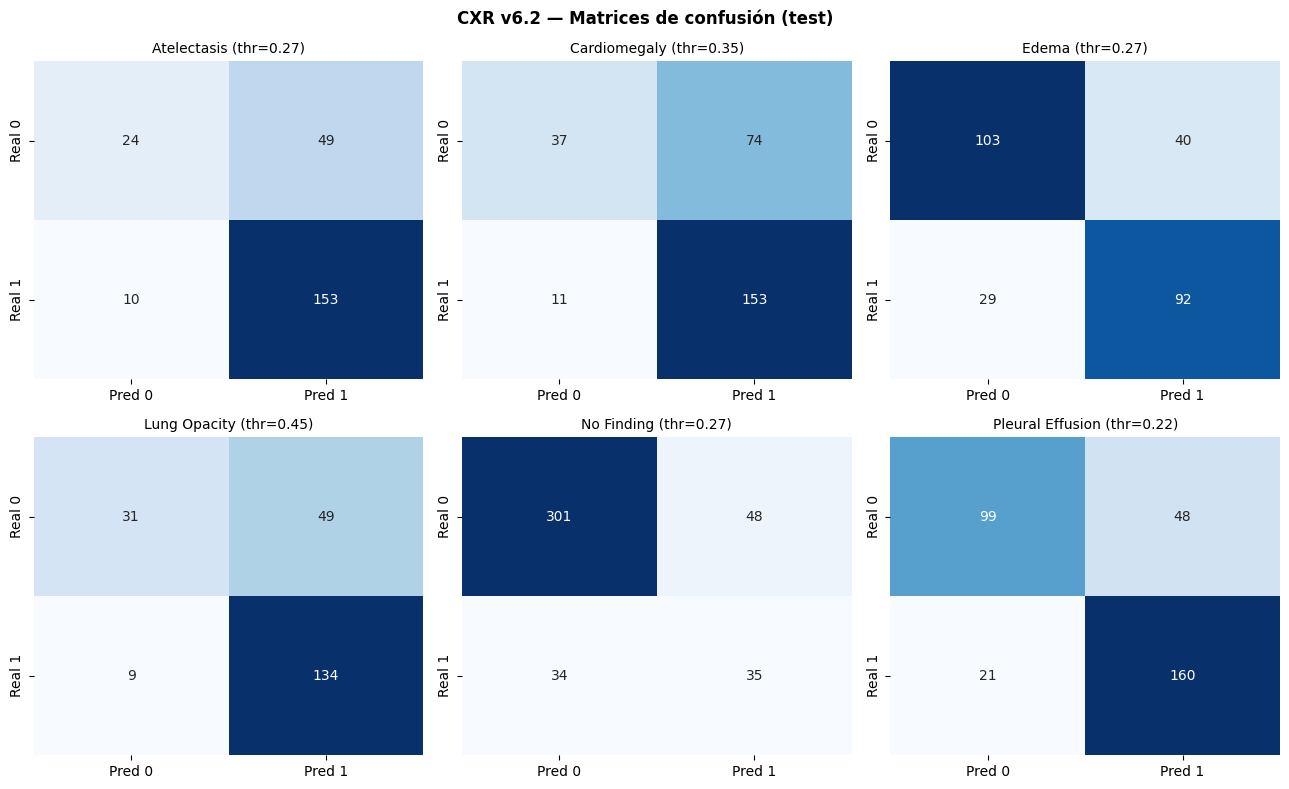

Guardadas.


In [28]:
# CELDA 13 · MATRICES DE CONFUSIÓN (test, por etiqueta)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("CXR v6.2 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_v6_2.png",dpi=150,bbox_inches="tight"); plt.show()
print("Guardadas.")


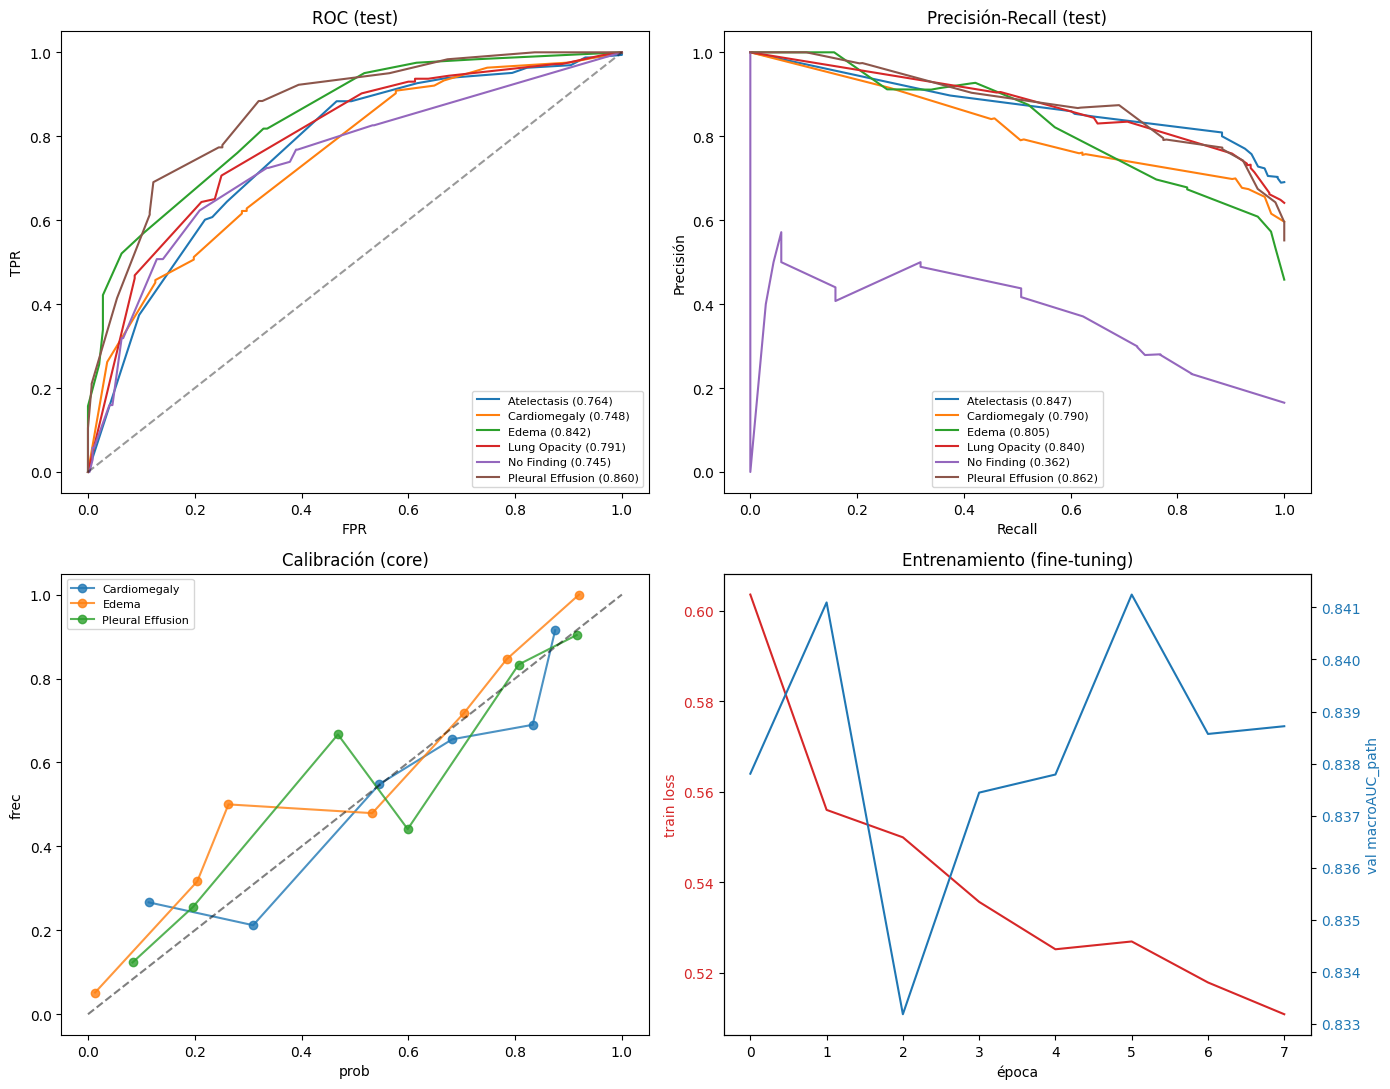

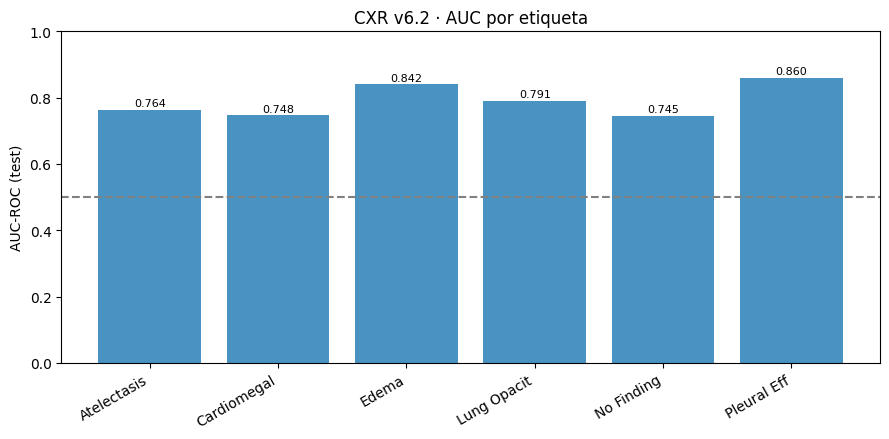

Figuras guardadas.


In [29]:
# CELDA 14 · CURVAS ROC / PR / CALIBRACIÓN / ENTRENAMIENTO + AUC
fig,axes=plt.subplots(2,2,figsize=(14,11))
ax=axes[0,0]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); ax.plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("ROC (test)"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
ax=axes[0,1]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    pr,rc,_=precision_recall_curve(yt,yp); ax.plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
ax.set_title("Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)
ax=axes[1,0]
for l in CORE_LABELS:
    j=LABELS.index(l); s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    bins=np.linspace(0,1,9); idx=np.digitize(yp,bins)-1; xs,ys=[],[]
    for b in range(len(bins)-1):
        mb=idx==b
        if mb.sum()>5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs,ys,"o-",label=l,alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5); ax.set_title("Calibración (core)"); ax.set_xlabel("prob"); ax.set_ylabel("frec"); ax.legend(fontsize=8)
ax=axes[1,1]; ax.plot(history["train_loss"],color="tab:red",label="train loss")
ax.set_xlabel("época"); ax.set_ylabel("train loss",color="tab:red"); ax.tick_params(axis="y",labelcolor="tab:red")
ax2=ax.twinx(); ax2.plot(history["val_auc"],color="tab:blue"); ax2.set_ylabel("val macroAUC_path",color="tab:blue"); ax2.tick_params(axis="y",labelcolor="tab:blue")
ax.set_title("Entrenamiento (fine-tuning)")
plt.tight_layout(); plt.savefig(FIG_DIR/"curvas_v6_2.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],color=["#c0392b" if (np.isnan(a) or a<0.55) else "#2980b9" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("CXR v6.2 · AUC por etiqueta")
for i,a in enumerate(aucs):
    if not np.isnan(a): ax.text(i,a+0.01,f"{a:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"auc_por_etiqueta_v6_2.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas.")


In [30]:
# CELDA 15 · EQUIDAD POR SUBGRUPO (test)
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("cxr_view","VISTA"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx]); print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.8062
   1                      n= 280  macroAUC_path=0.7954

-- AUC macro (patologías) por VISTA --
   AP                     n= 388  macroAUC_path=0.7763
   PA                     n=  76  macroAUC_path=0.8457

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.9403
   BLACK                  n=  58  macroAUC_path=0.7278
   HISPANIC_LATINO        n=  21  macroAUC_path=0.7279
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.8620
   WHITE                  n= 315  macroAUC_path=0.7950

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.7945
   OBSERVATION            n=  66  macroAUC_path=0.8251
   SCHEDULED              n=  34  macroAUC_path=0.6558
   URGENT                 n=  42  macroAUC_path=0.8610

Equidad completada.


---
## ✅ Conclusión — CXR v6.2

Versión pesada con **fine-tuning parcial** del DenseNet121 (último bloque descongelado), entrenamiento end-to-end
sobre imágenes con **aumento real**, **LR diferencial**, **TTA** y calibración. Mantiene negativos derivados,
masking intacto, metadatos y salidas ricas. Es el camino real para superar el techo del enfoque congelado de v6/v6.1,
a costa de **varias horas en CPU**. Si el AUC no mejora respecto a v6.1, prueba `UNFREEZE_DEEP=True` y más épocas.
